# Travel, Tourism & Hospitality
## Customer Retention and Dynamic Pricing Analysis

### Week 1 - Day 4

ADR Outlier Analysis

Dataset:
Hotel Booking Demand Dataset

Author:
Niveditha J

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed\hotel_bookings_feature_engineered.csv"
)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay_nights,total_guests,booking_changed,has_previous_cancellation,special_request_flag
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,1,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,1,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,98.0,0,1,Check-Out,2015-07-03,2,2.0,0,0,1


In [3]:
df.shape

(87370, 36)

## Average Daily Rate (ADR)

ADR represents the average revenue earned per occupied room.

Extreme ADR values can distort analysis and predictive modeling.
Therefore, ADR distribution must be examined before further analysis.

In [4]:
df['adr'].describe()

count    87370.000000
mean       106.346935
std         55.004259
min         -6.380000
25%         72.000000
50%         98.100000
75%        134.000000
max       5400.000000
Name: adr, dtype: float64

In [5]:
print("Minimum ADR:", df['adr'].min())
print("Maximum ADR:", df['adr'].max())

Minimum ADR: -6.38
Maximum ADR: 5400.0


## ADR Distribution

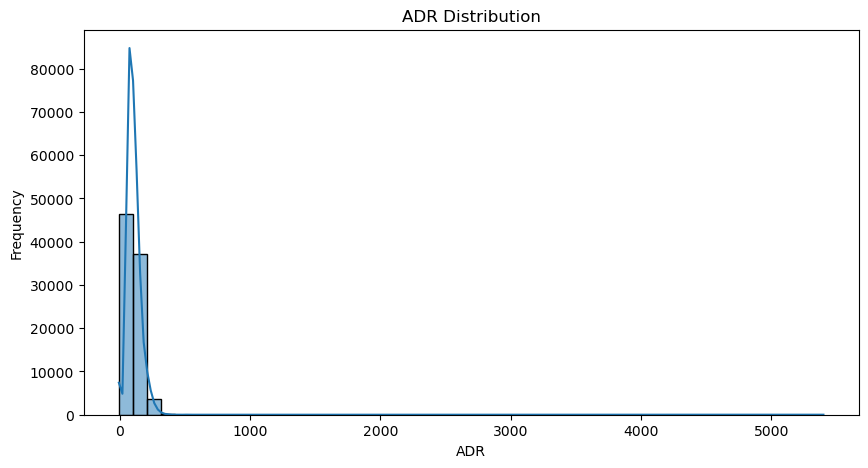

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['adr'],
    bins=50,
    kde=True
)

plt.title("ADR Distribution")
plt.xlabel("ADR")
plt.ylabel("Frequency")

plt.show()

The histogram helps identify skewness and unusual ADR values.

## Boxplot Analysis

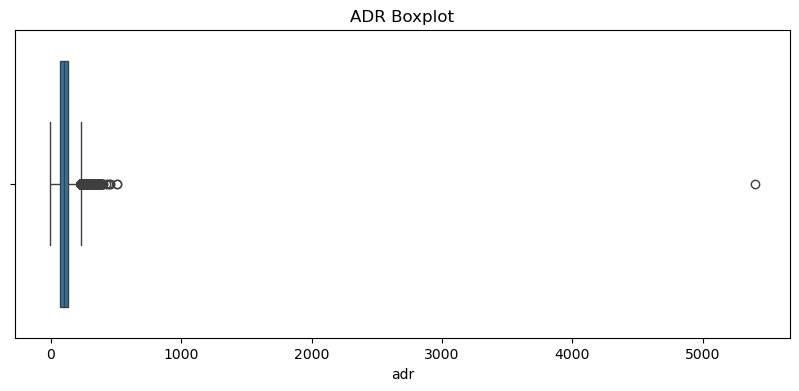

In [7]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['adr']
)

plt.title("ADR Boxplot")

plt.show()

The boxplot helps visualize extreme ADR values and potential outliers.

## IQR Method for Outlier Detection

In [8]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)

IQR = Q3 - Q1

Q1, Q3, IQR

(np.float64(72.0), np.float64(134.0), np.float64(62.0))

In [9]:
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -21.0
Upper Bound: 227.0


In [10]:
outliers = df[
    (df['adr'] < lower_bound) |
    (df['adr'] > upper_bound)
]

outliers.shape

(2488, 36)

In [11]:
outlier_percent = (len(outliers) / len(df)) * 100

print("Outlier Percentage:", round(outlier_percent,2), "%")

Outlier Percentage: 2.85 %


In [12]:
outliers['adr'].describe()

count    2488.000000
mean      261.816218
std       107.957702
min       227.060000
25%       236.000000
50%       250.000000
75%       272.000000
max      5400.000000
Name: adr, dtype: float64

## Findings

- ADR distribution was examined using histogram and boxplot.
- Potential outliers were identified using the IQR method.
- The number and percentage of outliers were calculated.
- Results from this analysis will be used in Day 5 for ADR outlier treatment.

### Business Interpretation

The ADR variable contains a small percentage of extreme values (2.85%).

These observations may represent luxury bookings, data-entry errors, or unusual market conditions.

Since extreme ADR values can distort predictive models and visualizations, ADR outlier treatment will be performed in Day 5 before proceeding with advanced analysis.

# Day 4 Conclusion

ADR values were analyzed to identify extreme observations that could affect future analysis and modeling.

Using the IQR method, potential outliers were detected and quantified.

The findings provide the foundation for ADR outlier treatment in Day 5.